# ЛР №2

## Упражнение 2.1
_____
Примеры выполнены

## Упражнение 2.2
_____

In [11]:
from thinkdsp.thinkdsp import *

In [12]:
class SawtoothSignal(Sinusoid):

    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / (2 * np.pi)
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)
        return ys

In [14]:
sawtooth = SawtoothSignal().make_wave(duration=2, framerate=30000)
sawtooth.make_audio()

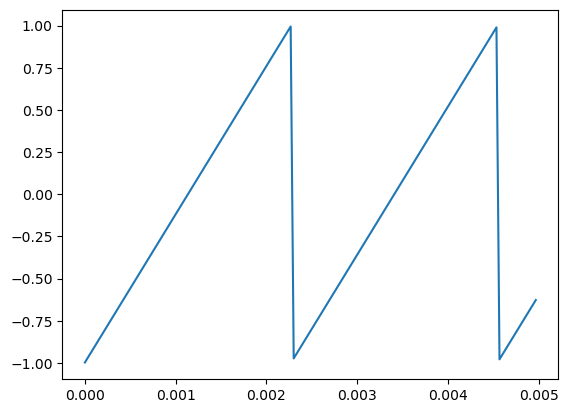

In [22]:
sawtooth.segment(start=0, duration=0.005).plot()

In [15]:
sawtooth_spectrum = sawtooth.make_spectrum()

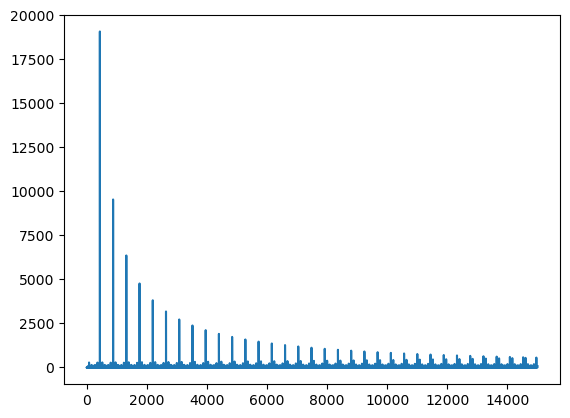

In [19]:
sawtooth_spectrum.plot()

В отличие от треугольного и прямоугольного сигналов спектр пилообразного сигнала содержит и четные, и нечетные гармоники, затухает сигнал как $1/f$

## Упражнение 2.3
_____

In [37]:
signal = SquareSignal(freq=1100).make_wave(framerate=10000, duration=1)

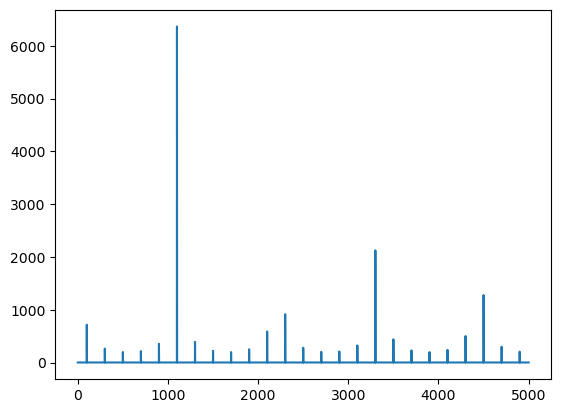

In [38]:
signal.make_spectrum().plot()

In [39]:
signal.make_audio()

Обычный прямоугольный сигнал для сравнения

In [40]:
SquareSignal(freq=500).make_wave(framerate=10000, duration=1).make_audio()

Разница слышна, с алиасингом на фоне присутствует некое "жужжание"

## Упражнение 2.4
_____

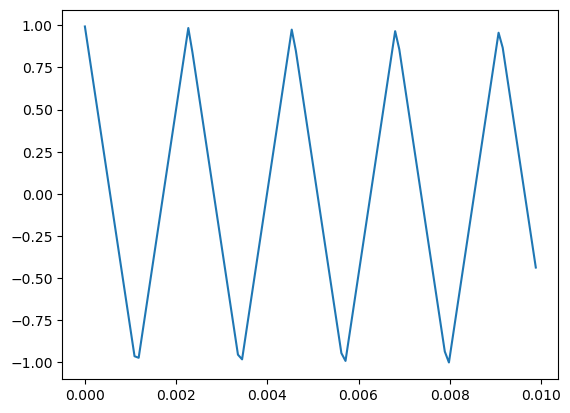

In [42]:
signal = TriangleSignal(freq=440).make_wave(duration=0.01)
signal.plot()

In [51]:
spectrum = signal.make_spectrum()

In [44]:
spectrum.hs[0]

np.complex128(1.0436096431476471e-14+0j)

In [45]:
signal.make_audio()

In [47]:
spectrum.hs[0] = 100

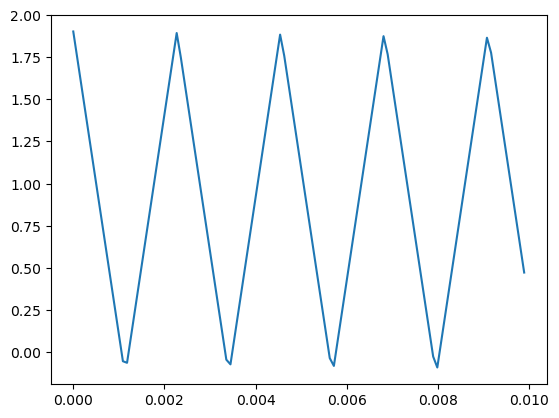

In [48]:
spectrum.make_wave().plot()
spectrum.make_wave().make_audio()

Амплитуда сдвинулась по оси y вверх. Изначально нулевая составляющая была практически равна 0, сигнал был несмещенный.

## Упражнение 2.5
_____

In [75]:
def div_spectrum(spectrum):
    spectrum.hs[0] = 0
    spectrum.hs[1:] /= spectrum.fs[1:]

In [76]:
signal = TriangleSignal(freq=440).make_wave(duration=0.5)
spectrum = signal.make_spectrum()
signal.make_audio()

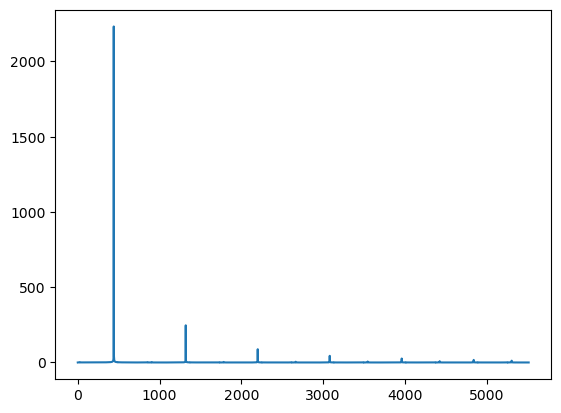

In [77]:
spectrum.plot()

In [78]:
div_spectrum(spectrum)

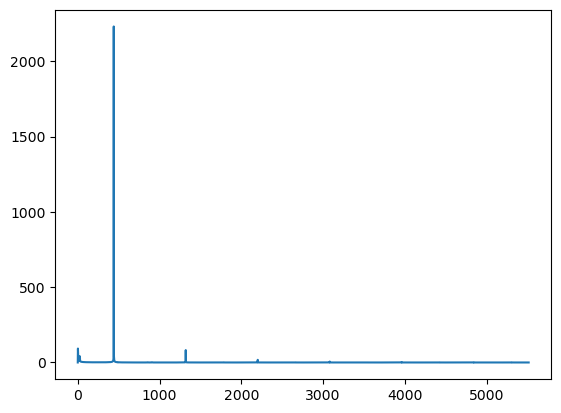

In [79]:
spectrum.scale(440)
spectrum.plot()

In [80]:
spectrum.make_wave().make_audio()

Функция подавляет гармоники в сигнале, тем самым получается фильтр нижних частот.

## Упражнение 2.6
_____
Создадим пилообразный сигнал, который включает четные и нечетные гармоники и применим к нему функцию из предыдущего упражнения, тем самым получим затухание сигнала пропорциональное $1/f$

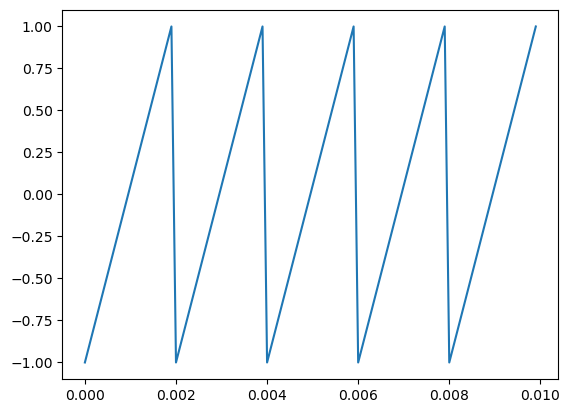

In [96]:
signal = SawtoothSignal(freq=500).make_wave(duration=0.01, framerate=10000)
spectrum = signal.make_spectrum()
signal.plot()

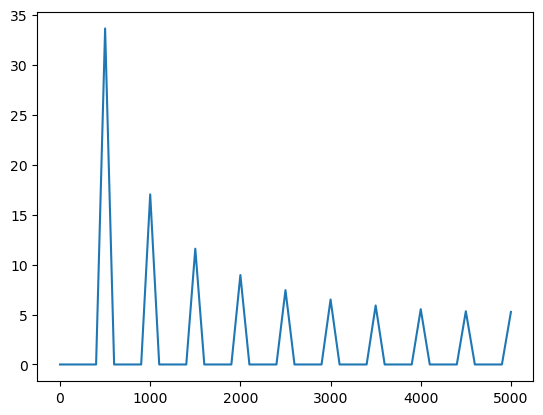

In [98]:
spectrum.plot()

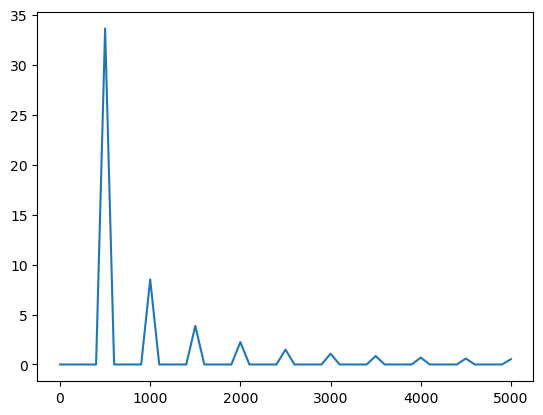

In [99]:
div_spectrum(spectrum)
spectrum.scale(500)
spectrum.plot()

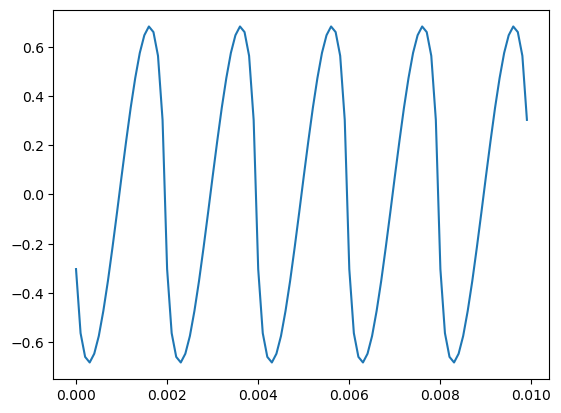

In [100]:
spectrum.make_wave().segment(start=0, duration=0.01).plot()